# Smoking Data EDA

건강검진 데이터를 기반으로 흡연 여부(label)와 관련된 주요 변수들을 탐색하고, 전처리 및 분석 방향을 결정한다.

In [67]:
# 경로 추가
import sys
import os

sys.path.append(os.path.abspath(".."))

In [68]:
# 라이브러리 & 데이터 로딩
import pandas as pd

# 시각화 함수(visualization.py) import
from src.visualization import (
    plot_missing_values,
    plot_target_distribution,
    plot_numeric_vs_target,
    plot_categorical_vs_target,
    plot_correlation_heatmap
)

df = pd.read_csv("../data/raw/smoking_health_data.csv")

df.head()

,ID,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label
0,TRAIN_0000,35,170,70,24.22,1.10,1,98.0,40.0,80.0,1.3,211,75,120,15.9,1,1.53,1
1,TRAIN_0001,40,150,55,24.44,1.00,0,173.0,39.0,104.0,0.6,251,46,184,11.8,1,1.45,0
2,TRAIN_0002,60,170,50,17.30,0.75,0,96.0,40.0,61.0,0.8,144,43,89,15.3,1,1.04,0
3,TRAIN_0003,40,150,45,20.00,0.50,0,92.0,40.0,46.0,0.7,178,66,110,13.4,1,1.18,0
4,TRAIN_0004,55,155,65,27.06,NaN,0,87.0,42.0,95.0,0.9,232,62,151,13.8,1,1.32,0


## 데이터 구조 확인
데이터의 크기, 타입, 기본 통계를 확인하여 전반적인 구조 파악

In [69]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ID        7000 non-null   str    
 1   나이        7000 non-null   int64  
 2   키(cm)     7000 non-null   int64  
 3   몸무게(kg)   7000 non-null   int64  
 4   BMI       7000 non-null   float64
 5   시력        6860 non-null   float64
 6   충치        7000 non-null   int64  
 7   공복 혈당     6860 non-null   float64
 8   혈압        6860 non-null   float64
 9   중성 지방     6860 non-null   float64
 10  혈청 크레아티닌  7000 non-null   float64
 11  콜레스테롤     7000 non-null   int64  
 12  고밀도지단백    7000 non-null   int64  
 13  저밀도지단백    7000 non-null   int64  
 14  헤모글로빈     7000 non-null   float64
 15  요 단백      7000 non-null   int64  
 16  간 효소율     7000 non-null   float64
 17  label     7000 non-null   int64  
dtypes: float64(8), int64(9), str(1)
memory usage: 984.5 KB


,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label
count,7000.000000,7000.000000,7000.000000,7000.000000,6860.000000,7000.000000,6860.000000,6860.000000,6860.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,43.973571,164.781429,65.932857,24.144423,1.011414,0.227429,99.307289,45.555102,127.028134,0.884900,197.276571,57.355429,115.346857,14.631914,1.083857,1.144696,0.367286
std,12.063793,9.170213,12.978702,3.501945,0.430137,0.419202,21.190058,8.831564,73.219161,0.241523,36.306494,14.506945,41.788153,1.540907,0.392051,0.432735,0.482100
min,20.000000,135.000000,30.000000,14.270000,0.100000,0.000000,57.000000,14.000000,21.000000,0.100000,86.000000,18.000000,1.000000,4.900000,1.000000,0.140000,0.000000
25%,35.000000,160.000000,55.000000,21.600000,0.800000,0.000000,89.000000,40.000000,74.000000,0.800000,173.000000,47.000000,92.000000,13.600000,1.000000,0.840000,0.000000
50%,40.000000,165.000000,65.000000,23.880000,1.000000,0.000000,96.000000,45.000000,107.000000,0.900000,195.000000,55.000000,113.000000,14.800000,1.000000,1.100000,0.000000
75%,50.000000,170.000000,75.000000,26.120000,1.200000,0.000000,104.000000,50.000000,161.000000,1.000000,219.000000,66.000000,136.000000,15.700000,1.000000,1.380000,1.000000
max,85.000000,190.000000,130.000000,42.450000,9.900000,1.000000,386.000000,91.000000,399.000000,10.000000,395.000000,157.000000,1340.000000,20.900000,5.000000,5.670000,1.000000


- 일부 변수에서 결측치가 존재 (시력, 공복 혈당, 혈압, 중성 지방) -> 140개씩 존재.

- 혈압은 일반적인 수축기/이완기 형태가 아닌 단일 값으로 구성되어 있으며, 이완기 혈압(DBP)일 가능성이 있다.
    - 최소값 14는 비정상적인 값(이상치)으로 판단되며 전처리 단계에서 처리 필요

- 시력의 최대값이 9.9 -> 이상치로 판단되며 전처리 단계에서 처리 필요
    - 원본 csv파일을 보면 0.85000000001처럼 부동소수점 오차(floating point error)가 존재하기 때문에 데이터 문제는 아니지만 표현의 통일성을 위해 round(2)로 정리 필요하다 판단

- 혈청 크레아티닌의 최대값이 10 -> 이상치로 판단되며 전처리 단계에서 처리 고려 (3이상도 심각한 신장 장애이기 때문)

- 저밀도지단백(LDL)의 최대값이 1340 -> 이상치로 판단되며 전처리 단계에서 처리 필요

- 헤모글로빈의 최소값과 최대값이 정상 범위에 포함되지 않는 이상치로 예상됨

- 요 단백은 범주형 데이터로 해석 가능 (1은 정상, 2~5는 이상)

- 간 효소율은 최대값이 5.67로 이상치 의심
    - 도메인 기준이 없으므로 EDA 단계에서는 보수적으로 접근
    - 분포 및 IQR 기반 통계적 방법으로 추가 검토 예정

- 타겟 변수: label (흡연 여부. 0 = 비흡연자, 1 = 흡연자)

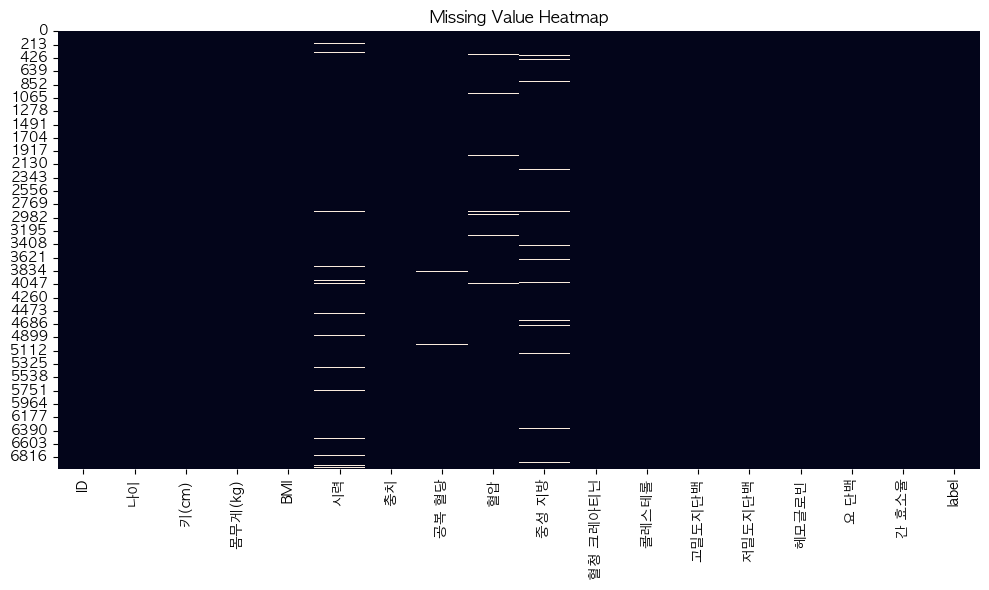

In [70]:
# 결측치 확인 (시각화)
plot_missing_values(df)

- 결측치는 특정 변수(시력, 공복 혈당, 혈압, 중성 지방)에 존재

- 데이터 전체에 랜덤하게 분포하는 것으로 보이며, 단순 제거보다는 적절한 대체 전략을 고려할 필요가 있어보임

## 타겟 변수 분포 확인
흡연 여부(label)의 분포를 확인하여 데이터 불균형 여부를 파악

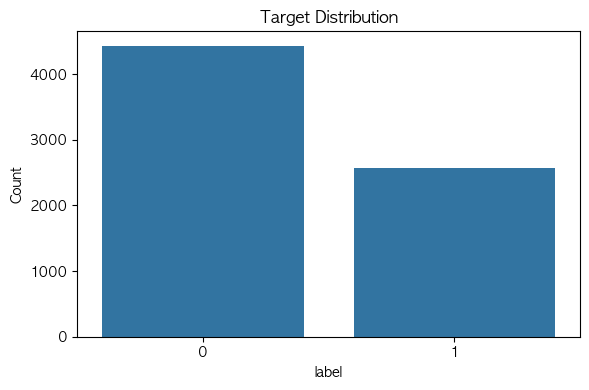

In [71]:
df["label"].value_counts()

plot_target_distribution(df)

- 비흡연자(0)은 약 4500, 비흡연자(1)은 약 2500으로 대략 65:35의 비율을 보임

- 해당 수준의 불균형은 실무에서 흔한 수준이며, EDA 단계에서는 추가적인 처리 없이 진행 가능

## 수치형 변수와 흡연 여부 관계 분석
주요 연속형 변수(BMI, 헤모글로빈, 중성 지방, 콜레스테롤, 저밀도지단백, 혈압)를 대상으로 흡연 여부에 따른 분포 차이 확인

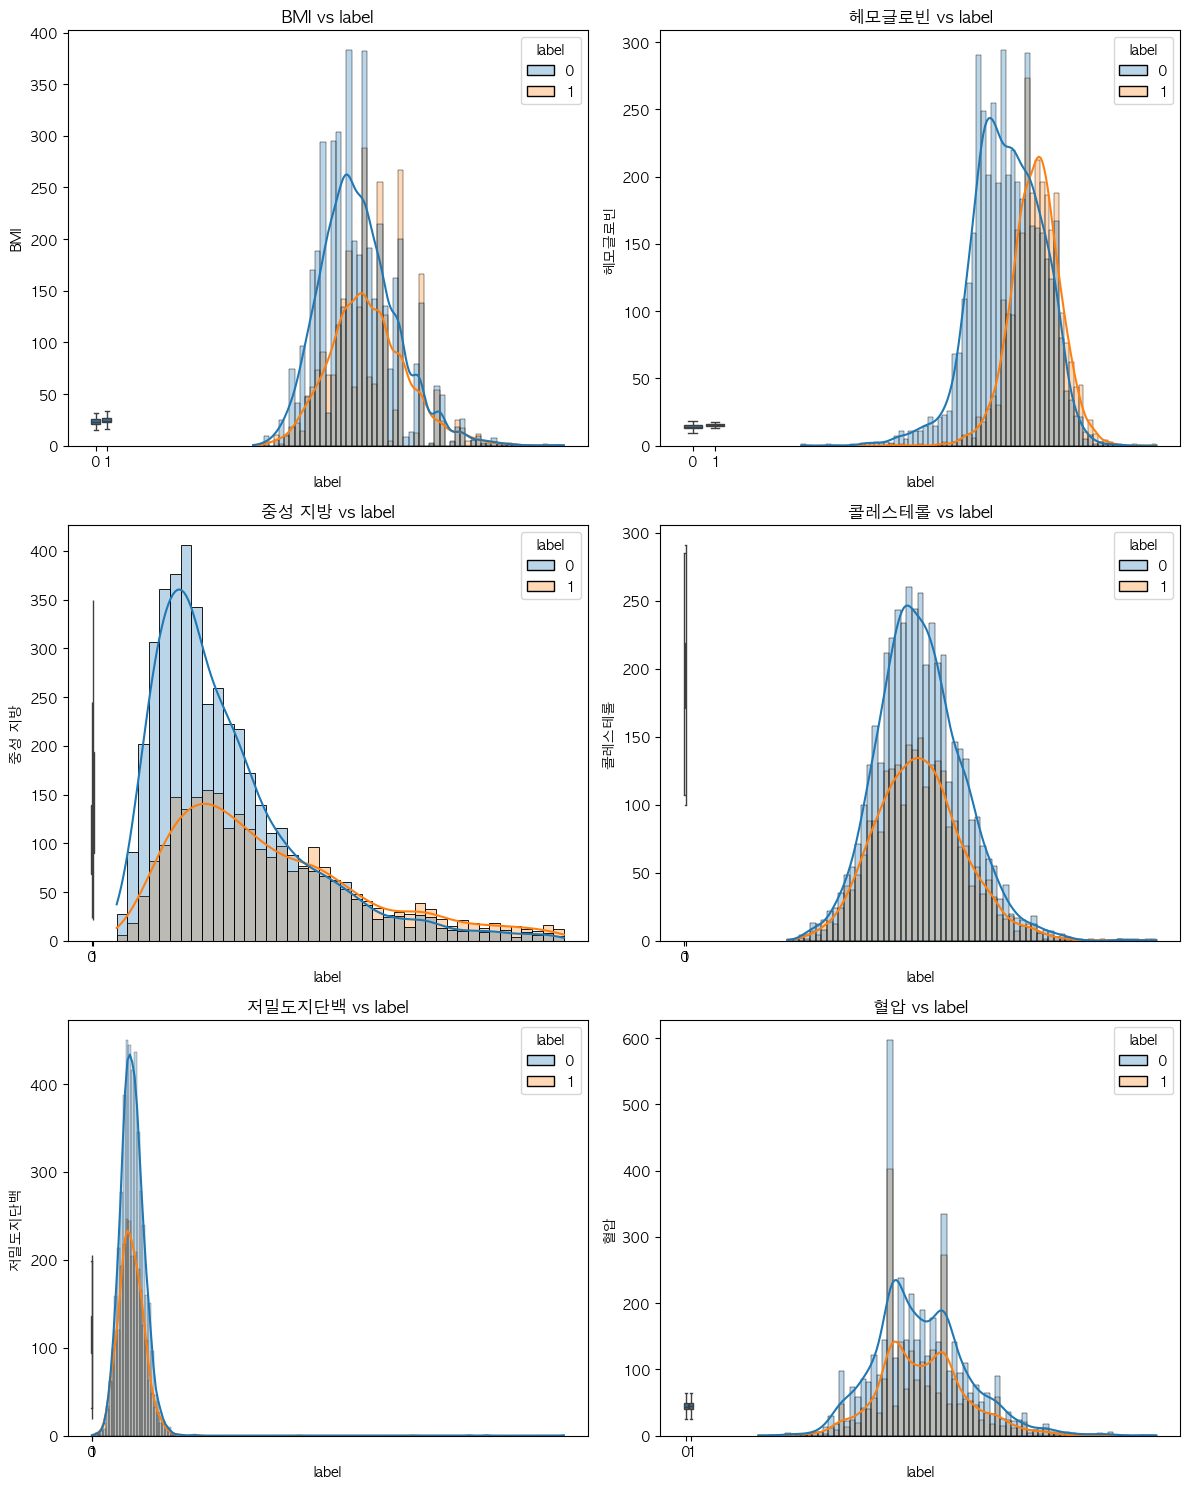

In [72]:
features = ["BMI", "헤모글로빈", "중성 지방", "콜레스테롤", "저밀도지단백", "혈압"]

plot_numeric_vs_target(df, features)

### 수치형 변수 종합 해석

- 헤모글로빈은 흡연자와 비흡연자 간 분포 차이가 명확하게 나타나며, 히스토그램에서도 두 그룹 간 분포가 비교적 분리되는 경향을 보임
  → 흡연 여부와의 관련성이 높은 주요 변수로 판단

- 중성 지방은 흡연자의 경우 상대적으로 높은 값의 비중이 증가하는 경향이 있으며, 분포가 오른쪽으로 치우쳐 있어 일부 극단값의 영향이 존재
  → 분포 왜곡이 있어 전처리 시 변환(log 등)을 고려할 수 있음

- BMI는 일부 차이가 존재하지만 두 그룹 간 분포가 상당 부분 겹쳐 있어, 흡연 여부를 구분하는 변수로서의 영향은 제한적일 것으로 보임

- 콜레스테롤과 저밀도지단백은 두 그룹 간 분포가 거의 동일하게 나타나며, 히스토그램에서도 큰 차이가 관찰되지 않는다.
  → 흡연 여부와의 관련성은 낮을 가능성이 있음
- 혈압 또한 그룹 간 분포 차이가 크지 않고, 전반적으로 겹치는 형태를 보임
  → 흡연 여부를 설명하는 변수로서의 영향은 제한적일 수 있음

## 범주형 변수 분석 (요 단백)
요 단백과 흡연 여부 간의 관계 확인

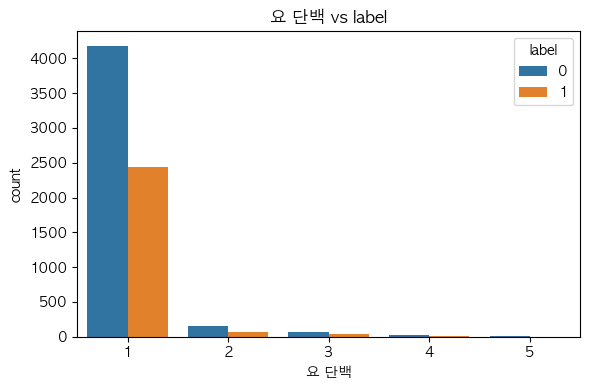

label,0,1
요 단백,,
1,0.631611,0.368389
2,0.675325,0.324675
3,0.607477,0.392523
4,0.588235,0.411765
5,0.800000,0.200000


In [73]:
plot_categorical_vs_target(df, "요 단백")

# 요 단백과 label 차이가 시각화 자료로는 비율 차이 확인이 어려워 교차표로 확인
pd.crosstab(df["요 단백"], df["label"], normalize="index")

- 대부분의 범주에서 흡연 비율이 전체 비율(약 65:35)과 유사하게 나타남

- 일부 값(4, 5)은 표본 수가 적어 변동성이 큼

→ 따라서, 요 단백은 흡연 여부를 설명하는 변수로서의 영향을 제한적일 것으로 보임

## 변수 간 상관관계 분석
수치형 변수 간의 상관관계를 통해 데이터의 전체 구조를 파악하고, 높은 상관관계를 가지는 변수들을 확인

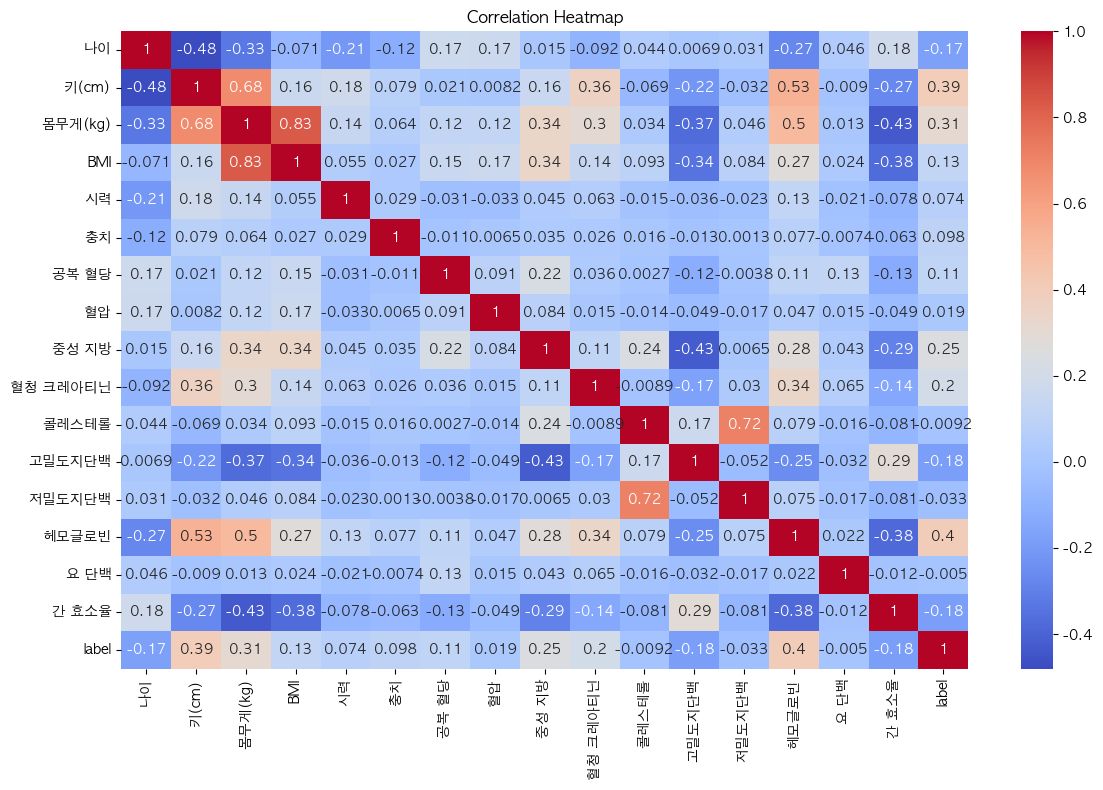

In [74]:
plot_correlation_heatmap(df)

- 일부 변수 간 높은 상관관계가 관찰되며,
  이는 다중공선성 가능성을 시사한다.

- 일반적으로 상관계수 0.7 이상은 높은 상관관계로 간주되며,
  변수 간 정보 중복 가능성이 존재한다.

- 예:
  - 몸무게 & BMI (0.83)
  - 콜레스테롤 & LDL (0.72)


## EDA 요약
- 헤모글로빈과 중성 지방은 흡연 여부에 따라 분포 차이가 관찰되어 주요 변수로 활용될 가능성이 있음

- BMI는 일부 차이가 존재하나, 상대적으로 영향은 제한적일 것으로 보임

- 혈압, 콜레스테롤, 저밀도지단백은 그룹 간 분포 차이가 뚜렷하지 않아 흡연 여부와의 관계가 명확하지 않음

- 요 단백은 값에 따른 흡연 비율 차이가 거의 나타나지 않아 설명력이 제한적인 변수로 보임

- 일부 변수 간 높은 상관관계가 관찰되며, 다중공선성 가능성 존재

→ 이후 전처리 및 가설 검증 단계에서 추가적인 분석을 진행할 예정

## 전처리 전략 설계

EDA 결과를 바탕으로 데이터 전처리 방향을 정의

- 결측치 처리
  - 시력 → 최빈값
  - 공복 혈당, 혈압, 중성 지방 → 중앙값

- 이상치 처리
  - 시력: 비정상 값 제거 또는 clipping
  - 혈압: 비정상적으로 낮은 값 제거 필요
  - 크레아티닌, LDL: 극단값 존재 → IQR 기반 처리 고려

- 분포 왜곡 변수
  - 중성 지방 → 로그 변환 고려

- 범주형 변수
  - 요 단백 → 범주형 처리 유지

- 변수 선택 방향
  - 헤모글로빈, 중성 지방 → 주요 변수 후보
  - 콜레스테롤, LDL → 우선순위 낮음

## 최종 인사이트 (핵심 요약)

- 흡연 여부와 가장 관련성이 높은 변수: 헤모글로빈, 중성 지방

- 구분력이 낮은 변수: 혈압, 콜레스테롤, LDL

- 데이터 이슈:
  - 결측치 존재 (시력, 공복 혈당, 혈압, 중성 지방)
  - 일부 변수에서 극단값 존재 (시력, 크레아티닌, LDL 등)

- 모델링 방향:
  - 헤모글로빈, 중성 지방 중심으로 feature 활용
  - 이상치 및 분포 왜곡 변수 전처리 필요

## 다음 단계

EDA를 통해 도출한 전처리 전략을 기반으로, 데이터 정제 및 feature engineering을 수행하고 흡연 여부 예측을 위한 분석을 진행 예정